In [1]:
from matplotlib import pyplot as plt
from func import *
import nn4n
import numpy as np
from rtgym.utils.data_processing import RatemapAggregator
from rtgym.utils.visualization import plot_ratemaps
import torch
from torch.utils.data import DataLoader, TensorDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Load the input and the label
# ===========================================================================================

# 2, 10 done
load_data_type = '2TS_trial'
load_dir = f'../data/'
data = np.load(f'{load_dir}/{load_data_type}.npy', allow_pickle=True).item()

train_inputs = torch.tensor(data[f'train_inputs'], dtype=torch.float32).to(device)
train_labels = torch.tensor(data[f'train_labels'], dtype=torch.float32).to(device)

# Create DataLoader for training and testing
train_dataset = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [4]:
# Initialise the RNN
# ===========================================================================================
num_neuron = 512

model_cfg = {
            "input_dim":    train_inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   train_inputs.shape[2],
            "alpha":        0.03,
            "learn_alpha":  False,
            "preact_noise": 0.3,
            "postact_noise":0.3
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)


def custom_loss(recon, target, firing_rates, lambda_mse, lambda_r):
    """
    Args:
        recon: [batch, time, dim] — reconstructed experience vectors (ŷ)
        target: [batch, time, dim] — ground truth experience vectors (y)
        firing_rates: [batch, time, N] — firing rates of all hidden neurons
    """

    # Shape values
    B, T, D = target.shape
    N = firing_rates[0].shape[2]

    # 1. Reconstruction MSE Loss
    mse = torch.sum((recon - target) ** 2) / (B * T * D)
    # mse = torch.nn.MSELoss()
    # mse = mse(recon, target)

    # 2. Firing rate regularization term
    reg = torch.sum(torch.sum(firing_rates[0], axis=(0,1))**2 / (B * T)) / N

    total_loss = lambda_mse * mse + lambda_r * reg
    # print(lambda_mse * mse, lambda_r * reg)
    return total_loss, lambda_mse * mse, lambda_r * reg


optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [5]:
# Train the RNN
# ===========================================================================================
    
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(10000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        # loss = criterion(batch_outputs, batch_labels)
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001
                           ) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 100 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)
    # if loss1 < 0.02:
    #     print("Early stopping due to low MSE loss.")
    #     break
    if  losses[-1] < 0.1 and abs(losses[-1] - losses[-50]) < 1e-4: # len(losses) > 50  :
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

  0%|          | 1/10000 [00:00<2:20:49,  1.18it/s]

Epoch 0 Loss 0.8394023776054382
tensor(0.7721, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0673, device='cuda:0', grad_fn=<MulBackward0>)


  1%|          | 101/10000 [01:01<1:31:41,  1.80it/s]

Epoch 100 Loss 0.298603892326355
tensor(0.2524, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0462, device='cuda:0', grad_fn=<MulBackward0>)


  2%|▏         | 201/10000 [01:57<1:31:07,  1.79it/s]

...

Epoch 1500 Loss 0.14413489401340485
tensor(0.1126, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0315, device='cuda:0', grad_fn=<MulBackward0>)


 16%|█▌        | 1601/10000 [19:29<1:17:45,  1.80it/s]

Epoch 1600 Loss 0.1382877677679062
tensor(0.1074, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0309, device='cuda:0', grad_fn=<MulBackward0>)


 16%|█▌        | 1613/10000 [19:36<1:41:58,  1.37it/s]


KeyboardInterrupt: 

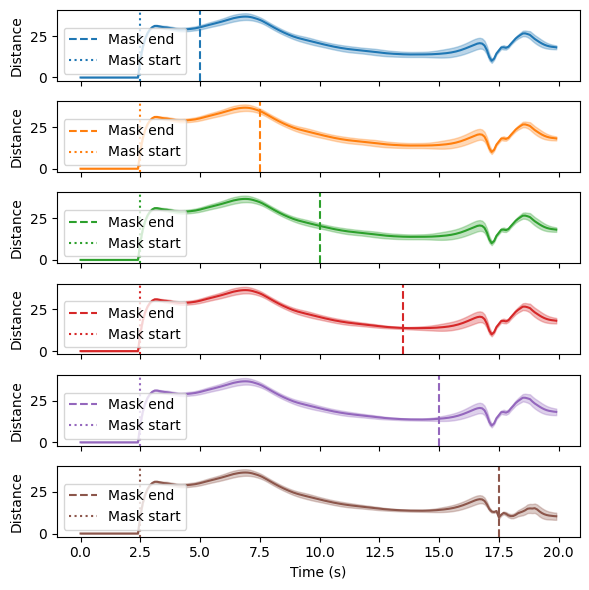

In [7]:
# ===========================================================================================
# Compute the higher dimensional distance
# ===========================================================================================\

exp_vectors = torch.tensor(data['test_labels'], dtype=torch.float32).to(device)

rnn.eval()
with torch.no_grad():
    _, ref_fr = rnn(exp_vectors)
ref_fr = ref_fr[0].cpu().numpy()

# Partially mask the input
mask_start = 25
mask_indices = [50, 75, 100, 135, 150, 175]

# Set up the figure
fig, ax = plt.subplots(len(mask_indices), 1, figsize=(6, len(mask_indices)), sharex=True)
for idx, mask_idx in enumerate(mask_indices):
    
    exp_vectors[:, mask_start:mask_idx, :] = 0
    
    # fr = RNNnet.run(exp_vectors)   # -> shape (B,T,N)
    fr = rnn(exp_vectors)[1].cpu().numpy()
    
    # Compute the higher dimensional distance
    dist = np.linalg.norm(fr - ref_fr, axis=-1)[0]  # (B,T)

    # Get the mean and std over batch
    mean_dist = np.mean(dist, axis=0)  # (T,)
    std_dist = np.std(dist, axis=0)    # (T,)
    
    # Plot the distance with error bars
    ax[idx].plot(np.arange(mean_dist.shape[0])/10, mean_dist, color=f'C{idx}')
    ax[idx].fill_between(np.arange(mean_dist.shape[0])/10, 
                    mean_dist - std_dist,
                    mean_dist + std_dist,
                    color=f'C{idx}', alpha=0.3)
    # Plot the vertical dashed line at the mask point
    ax[idx].axvline(x=mask_idx/10, color=f'C{idx}', linestyle='--', label='Mask end')
    ax[idx].axvline(x=mask_start/10, color=f'C{idx}', linestyle=':', label='Mask start')
    ax[idx].set_ylabel('Distance')
    ax[idx].legend()
    # ax[idx].set_ylim(0, 40)
    
plt.xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'../output/higher_dim_distance(RealModel-{load_data_type}).png')

In [8]:
### Compute the Jacobian stability over time ###
from theory_exp.jacobian import compute_jacobian_over_time2
exp_vectors = torch.tensor(data['test_labels'], dtype=torch.float32).to(device)

max_real_c, _, eigen_c, _ = compute_jacobian_over_time2(rnn, exp_vectors, return_full_spectrum=True) # (B, T,) (B, T,)

100%|██████████| 50/50 [06:12<00:00,  7.45s/it]


Text(0.5, 1.0, 'Continuous-time local stability')

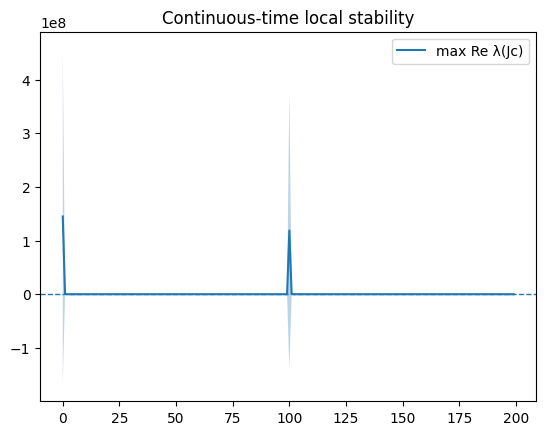

In [9]:
plt.figure(); 
# Plot the mean over trials
plt.plot(max_real_c.mean(axis=0), label="max Re λ(Jc)")
# plt.ylim(-1, 3)
# Plot the 1 std shaded area
plt.fill_between(np.arange(max_real_c.shape[1]), 
                 max_real_c.mean(axis=0)-max_real_c.std(axis=0),
                 max_real_c.mean(axis=0)+max_real_c.std(axis=0),
                 alpha=0.3)
plt.axhline(0, ls='--', lw=1); plt.legend(loc='best'); plt.title("Continuous-time local stability")

In [ ]:
# Test the RNN
# ===========================================================================================

test_inputs = torch.tensor(data['test_inputs'], dtype=torch.float32).to(device)

rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

In [ ]:
# Plot the test outputs vs the test labels
test_inputs = data['test_inputs']
test_labels = data['test_labels']
fig, ax = plt.subplots(1,2, figsize=(10,5))
for i in range(3):
    ax[1].plot(test_labels[0,:,i], label='label', color=f'C{i}')
    ax[1].plot(test_outputs[0,:,i], label='Pred', linestyle='dotted', color=f'C{i}')
    ax[0].plot(test_inputs[0,:,i], label='Input', linestyle='--', color=f'C{i}')
ax[0].legend()

In [ ]:
# Plot the test outputs vs the test labels
test_labels = data['test_labels']
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(test_labels[0].T, aspect='auto', cmap='binary')
ax[0].set_title('Test Labels')
ax[1].imshow(test_outputs[0].T, aspect='auto', cmap='binary')
ax[1].set_title('Test Outputs from RNN')
plt.show()

In [ ]:
# Plot the difference between the test labels and the test outputs
fig, ax = plt.subplots(figsize=(10,5))
ax.imshow(test_labels[0].T - test_outputs[0].T, aspect='auto', cmap='bwr', vmin=-1, vmax=1)
ax.set_title('Difference between Test Labels and Test Outputs')
# Plot colorbar
cbar = plt.colorbar(mappable=plt.cm.ScalarMappable(cmap='bwr'), ax=ax)
cbar.set_label('Difference')
plt.show()

In [ ]:
def plt_hs(hs, min_fr=0.1, fig=None, ax=None):

    time_points, num_neurons = hs.shape[0], hs.shape[1]

    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_points/10, 0, num_neurons]
              )
    # ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))
    
    return norm_hs, fig, ax

In [ ]:
# Averge accross the batch
avg_hs = np.mean(hidden_states, axis=0)
print(avg_hs.shape)

# pre and post noise = 0.3, fr
fig, ax = plt.subplots(figsize=(6, 4))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax)
print(norm_hs.shape)
plt.savefig(f'hidden_states(RealModel-{load_data_type}).png', transparent=True)

### temporal test

In [ ]:
# Sort the norm_hs with maximum firing time
max_time_pts = np.argmax(norm_hs, axis=0)

threshold = 0.7
delta = 0.1

# For regions left to the max time pts, find the index where the firing rate is closest to 0.7 and between 0.65 and 0.75
firing_starts = np.zeros(norm_hs.shape[1])
for i in range(norm_hs.shape[1]):
    left_half = norm_hs[:max_time_pts[i], i]
    if np.any((left_half > threshold-delta) & (left_half < threshold+delta)):
        firing_starts[i] = np.where((left_half > threshold-delta) & (left_half < threshold+delta))[0][-1]
        
    else:
        firing_starts[i] = np.nan

# For regions right to the max time pts, find the index where the firing rate is closest to 0.7 and between 0.65 and 0.75
firing_ends = np.zeros(norm_hs.shape[1])
for i in range(norm_hs.shape[1]):
    right_half = norm_hs[max_time_pts[i]:, i]
    if np.any((right_half > threshold-delta) & (right_half < threshold+delta)):
        firing_ends[i] = max_time_pts[i] + np.where((right_half > threshold-delta) & (right_half < threshold+delta))[0][0]
    else:
        firing_ends[i] = np.nan

firing_widths = firing_ends - firing_starts

# Change the unit to time (s)
max_time_pts = max_time_pts / 10
firing_starts = firing_starts / 10
firing_ends = firing_ends / 10
firing_widths = firing_widths / 10

In [ ]:
def plt_corr(time_pts, widths, fig, ax):
    
    # calculate the fitted gradient
    from scipy.optimize import curve_fit
    def fit_func(x, a, b):
        return a * x + b
    popt, pcov = curve_fit(fit_func, time_pts, widths)  
    print(f'Fitted gradient: {popt[0]:.4f}')

    # use seaborn to plot the correlation of red dots with shaded area
    import seaborn as sns
    rval = np.corrcoef(time_pts, widths)[0,1]
    print(f'Correlation coefficient: {rval}')
    sns.regplot(x=time_pts, y=widths,
                scatter=False, 
                color='black',
                line_kws={"linewidth":1, "linestyle":"-"},
                ci=95,
                label=f'r = {rval:.2f}; gradient = {popt[0]:.4f}')



    return fig, ax

In [ ]:
# Plot the firing widths vs the maximum firing times
fig, ax = plt.subplots(figsize=(5,2))

plt.scatter(max_time_pts[(firing_starts >= 0) & (firing_ends <= 5)], 
            firing_widths[(firing_starts >= 0) & (firing_ends <= 5)], 
            c='skyblue', s=10)
plt_corr(max_time_pts[(firing_starts >= 0) & (firing_ends <= 5)], 
         firing_widths[(firing_starts >= 0) & (firing_ends <= 5)], 
         fig=fig, ax=ax)

plt.scatter(max_time_pts[(firing_starts >= 5) & (firing_ends <= 10)], 
            firing_widths[(firing_starts >= 5) & (firing_ends <= 10)], 
            c='salmon', s=10)
plt_corr(max_time_pts[(firing_starts >= 5) & (firing_ends <= 10)], 
         firing_widths[(firing_starts >= 5) & (firing_ends <= 10)], 
         fig=fig, ax=ax)

plt.xlabel('Maximum firing time (s)')
plt.ylabel("Firing width (s)")
plt.legend()
plt.show()

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(5, 4), sharex=True)
_, fig, axs[0] = plt_hs(norm_hs[:, (firing_starts >= 0) & (firing_ends <= 5)], 
                    min_fr=0.1, fig=fig, ax=axs[0])

select_idx = np.where((firing_starts >= 0) & (firing_ends <= 5))[0]
# Draw dashed lines at firing starts and ends
dashed_starts, dashed_ends, y = [], [], []
for idx, i in enumerate(select_idx):
    if (firing_starts[i] >= 0) and (firing_ends[i] <= 5):
        dashed_starts.append(firing_starts[i])
        dashed_ends.append(firing_ends[i])
        y.append(idx)
axs[0].plot(dashed_starts[::-1], y, color='black', linestyle='--', linewidth=0.5)
axs[0].plot(dashed_ends[::-1], y, color='black', linestyle='--', linewidth=0.5)
axs[0].set_xlim(0, 5)

axs[1].scatter(max_time_pts[(firing_starts >= 0) & (firing_ends <= 5)], 
            firing_widths[(firing_starts >= 0) & (firing_ends <= 5)], 
            c='salmon', s=10)
plt_corr(max_time_pts[(firing_starts >= 0) & (firing_ends <= 5)], 
         firing_widths[(firing_starts >= 0) & (firing_ends <= 5)], 
         fig=fig, ax=axs[1])
plt.legend()
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel("Firing width (s)")
plt.savefig(f'../output/firing_width_vs_time(RealModel-{load_data_type})_part1.png', transparent=True)

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(5, 4), sharex=True)
_, fig, axs[0] = plt_hs(norm_hs[:, (firing_starts >= 5) & (firing_ends <= 10)], 
                    min_fr=0.1, fig=fig, ax=axs[0])

select_idx = np.where((firing_starts >= 5) & (firing_ends <= 10))[0]
# Draw dashed lines at firing starts and ends
dashed_starts, dashed_ends, y = [], [], []
for idx, i in enumerate(select_idx):
    if (firing_starts[i] >= 5) and (firing_ends[i] <= 10):
        dashed_starts.append(firing_starts[i])
        dashed_ends.append(firing_ends[i])
        y.append(idx)
axs[0].plot(dashed_starts[::-1], y, color='black', linestyle='--', linewidth=0.5)
axs[0].plot(dashed_ends[::-1], y, color='black', linestyle='--', linewidth=0.5)
axs[0].set_xlim(5, 10)

axs[1].scatter(max_time_pts[(firing_starts >= 5) & (firing_ends <= 10)], 
            firing_widths[(firing_starts >= 5) & (firing_ends <= 10)], 
            c='salmon', s=10)
plt_corr(max_time_pts[(firing_starts >= 5) & (firing_ends <= 10)], 
         firing_widths[(firing_starts >= 5) & (firing_ends <= 10)], 
         fig=fig, ax=axs[1])
plt.legend()
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel("Firing width (s)")
plt.savefig(f'../output/firing_width_vs_time(RealModel-{load_data_type})_part2.png', transparent=True)

### Plot place cells

In [ ]:
import os

aggregator = RatemapAggregator(data['arena_map'], device='cuda')

aggregator.update(norm_hs[:, (firing_starts >= 5) & (firing_ends <= 10)], 
                  data['test_traj']['coords'][:, 50:100, :])
ratemap = aggregator.get_ratemap().cpu().numpy()
print(ratemap.shape)

save_dir = f'{load_data_type}_{num_neuron}_ratemap_time{5}-{10}/'
os.makedirs(save_dir, exist_ok=True)

# Convert all zero to nan
ratemap[ratemap == 0] = np.nan

# # select_indices = [i for i in range(ratemap.shape[0]) if decisions[i]]
select_indices = range(num_neuron)
# Plot the ratemap
for imap in tqdm(select_indices):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)  
    ax.imshow(ratemap[imap], cmap='jet', aspect='auto')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/ratemap_neuron_{imap}', transparent=True)
    plt.close(fig)

### Save the model weights and data output

In [ ]:
model_dir = f'{load_dir}/rnn_model/'
torch.save(rnn.state_dict(), f'{model_dir}/{load_data_type}_{model_cfg["hidden_dim"]}.pth')

In [ ]:
data[f'loss_{model_cfg["hidden_dim"]}'] = losses
data[f'test_outputs_{model_cfg["hidden_dim"]}'] = test_outputs
data[f'hidden_states_{model_cfg["hidden_dim"]}'] = hidden_states
print(data.keys())

In [ ]:
print(f'{load_dir}/{load_data_type}.npy')
np.save(f'{load_dir}/{load_data_type}.npy', data, allow_pickle=True)